In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("Setup complete!")

Matplotlib is building the font cache; this may take a moment.


Setup complete!


In [3]:
df=pd.read_csv('covid_19_india.csv')
print(df.head())

   Sno        Date     Time State/UnionTerritory ConfirmedIndianNational  \
0    1  2020-01-30  6:00 PM               Kerala                       1   
1    2  2020-01-31  6:00 PM               Kerala                       1   
2    3  2020-02-01  6:00 PM               Kerala                       2   
3    4  2020-02-02  6:00 PM               Kerala                       3   
4    5  2020-02-03  6:00 PM               Kerala                       3   

  ConfirmedForeignNational  Cured  Deaths  Confirmed  
0                        0      0       0          1  
1                        0      0       0          1  
2                        0      0       0          2  
3                        0      0       0          3  
4                        0      0       0          3  


In [4]:
# Check what columns are in the dataset
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Sno', 'Date', 'Time', 'State/UnionTerritory', 'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured', 'Deaths', 'Confirmed']


In [25]:
# ===== DATA CLEANING: Fix State Names =====

# Step 1: Remove extra spaces
df['State/UnionTerritory'] = df['State/UnionTerritory'].str.strip()

# Step 2: Remove asterisks and special characters
df['State/UnionTerritory'] = df['State/UnionTerritory'].str.replace('*', '', regex=False)
df['State/UnionTerritory'] = df['State/UnionTerritory'].str.replace('#', '', regex=False)

# Step 3: Fix specific spelling errors and variations
state_name_fixes = {
    'Himanchal Pradesh': 'Himachal Pradesh',
    'Karanataka': 'Karnataka',
    'Telengana': 'Telangana',
    'Daman & Diu': 'Dadra and Nagar Haveli and Daman and Diu',
    'Dadra and Nagar Haveli': 'Dadra and Nagar Haveli and Daman and Diu',
}
df['State/UnionTerritory'] = df['State/UnionTerritory'].replace(state_name_fixes)

# Step 4: Remove administrative rows (not actual states)
rows_to_remove = ['Cases being reassigned to states', 'Unassigned']
df = df[~df['State/UnionTerritory'].isin(rows_to_remove)]

# Step 5: Verify cleaning worked
print("✅ State names cleaned!")
print(f"Number of unique states/UTs: {df['State/UnionTerritory'].nunique()}")
print("\nCleaned state list:")
print(sorted(df['State/UnionTerritory'].unique()))

✅ State names cleaned!
Number of unique states/UTs: 36

Cleaned state list:
['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [26]:
# How much data do we have?
print(f"Total rows: {len(df)}")
print(f"\nDate range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nNumber of States/UTs: {df['State/UnionTerritory'].nunique()}")
print(f"\nStates/UTs in dataset:")
print(df['State/UnionTerritory'].unique())

Total rows: 18047

Date range: 2020-01-30 00:00:00 to 2021-08-11 00:00:00

Number of States/UTs: 36

States/UTs in dataset:
<StringArray>
[                                  'Kerala',
                                'Telangana',
                                    'Delhi',
                                'Rajasthan',
                            'Uttar Pradesh',
                                  'Haryana',
                                   'Ladakh',
                               'Tamil Nadu',
                                'Karnataka',
                              'Maharashtra',
                                   'Punjab',
                        'Jammu and Kashmir',
                           'Andhra Pradesh',
                              'Uttarakhand',
                                   'Odisha',
                               'Puducherry',
                              'West Bengal',
                             'Chhattisgarh',
                               'Chandigarh',
       

In [27]:
# Convert Date to proper date format
df['Date'] = pd.to_datetime(df['Date'])

# Remove any rows with missing state names
df = df[df['State/UnionTerritory'].notna()]

print("✅ Data cleaned!")
print(f"Total rows after cleaning: {len(df)}")

✅ Data cleaned!
Total rows after cleaning: 18047


In [29]:
# Get the most recent data (latest totals for each state)
latest_data = df.groupby('State/UnionTerritory')[['Confirmed', 'Deaths', 'Cured']].max()

# Calculate national totals
national_confirmed = latest_data['Confirmed'].sum()
national_deaths = latest_data['Deaths'].sum()
national_cured = latest_data['Cured'].sum()

# Calculate CFR (Case Fatality Rate) - KEY EPIDEMIOLOGICAL METRIC!
national_cfr = (national_deaths / national_confirmed) * 100

print("=== INDIA COVID-19 SUMMARY ===")
print(f"Total Confirmed Cases: {national_confirmed:,}")
print(f"Total Deaths: {national_deaths:,}")
print(f"Total Recovered: {national_cured:,}")
print(f"\n📊 Case Fatality Rate (CFR): {national_cfr:.2f}%")

=== INDIA COVID-19 SUMMARY ===
Total Confirmed Cases: 32,036,511
Total Deaths: 429,179
Total Recovered: 31,220,981

📊 Case Fatality Rate (CFR): 1.34%


In [30]:
# Calculate CFR for each state
latest_data['CFR'] = (latest_data['Deaths'] / latest_data['Confirmed']) * 100

# Show top 10 states with highest CFR
print("Top 10 States by Case Fatality Rate:")
print(latest_data.nlargest(10, 'CFR')[['Confirmed', 'Deaths', 'CFR']])

Top 10 States by Case Fatality Rate:
                             Confirmed  Deaths       CFR
State/UnionTerritory                                    
Punjab                          599573   16322  2.722271
Uttarakhand                     342462    7368  2.151480
Maharashtra                    6363442  134201  2.108937
Nagaland                         28811     585  2.030474
Goa                             172085    3164  1.838626
Delhi                          1436852   25068  1.744647
Andaman and Nicobar Islands       7548     129  1.709062
Meghalaya                        69769    1185  1.698462
Himachal Pradesh                208616    3537  1.695460
Manipur                         105424    1664  1.578388


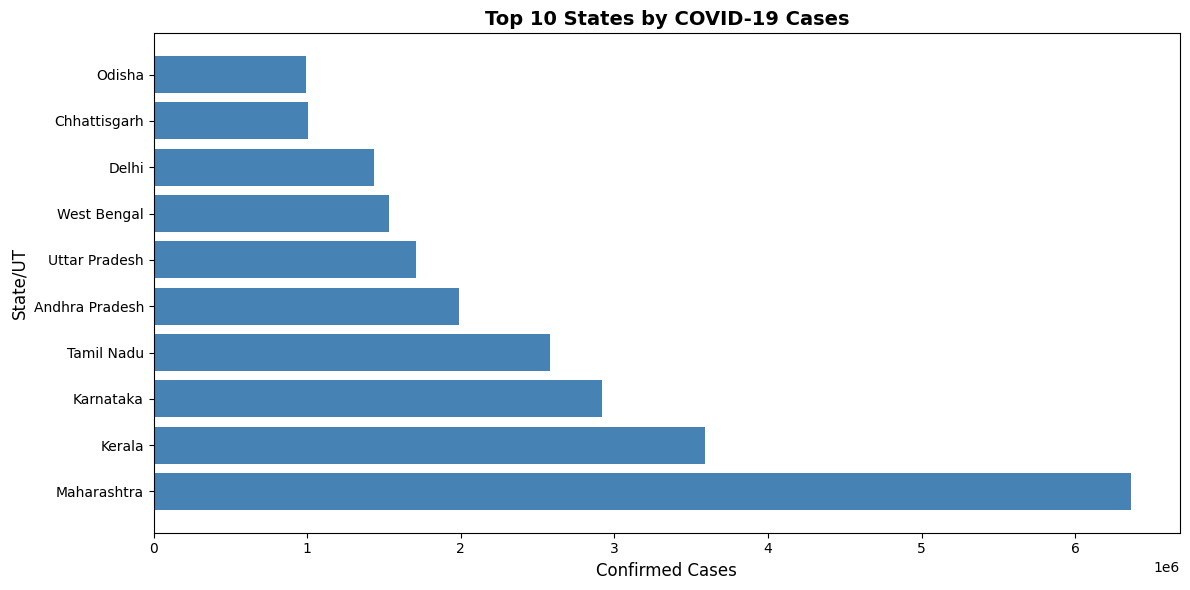

✅ Graph saved as 'top_10_states.png'


In [31]:
# Get top 10 states by total cases
top_10_states = latest_data.nlargest(10, 'Confirmed')

# Create bar chart
plt.figure(figsize=(12, 6))
plt.barh(top_10_states.index, top_10_states['Confirmed'], color='steelblue')
plt.xlabel('Confirmed Cases', fontsize=12)
plt.ylabel('State/UT', fontsize=12)
plt.title('Top 10 States by COVID-19 Cases', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the graph
plt.savefig('top_10_states.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved as 'top_10_states.png'")

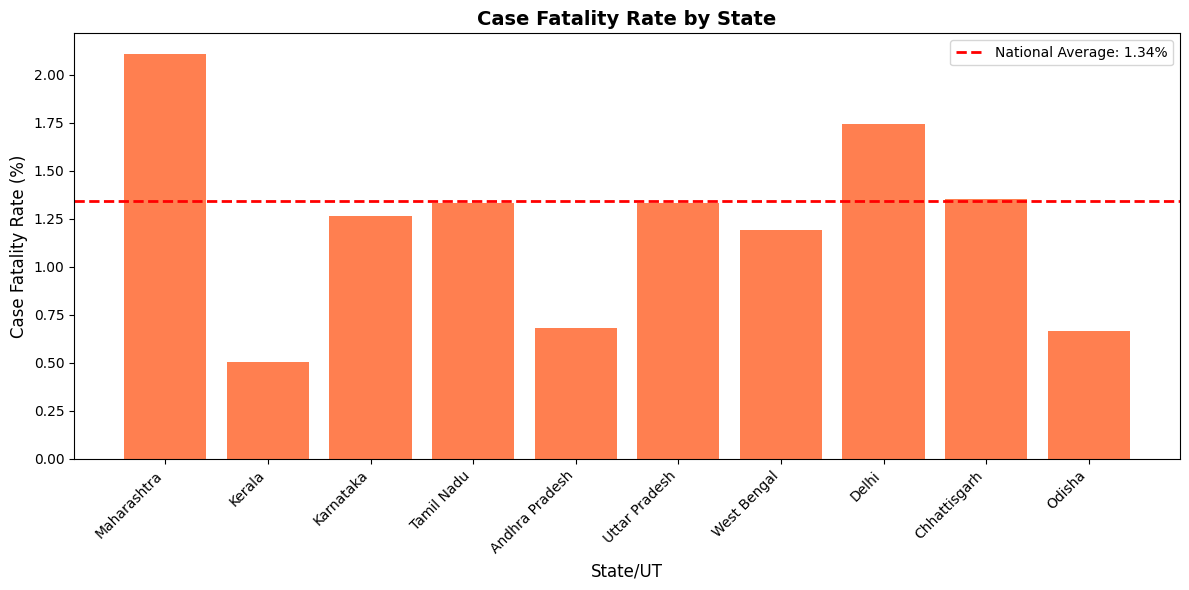

✅ Graph saved!


In [32]:
# Compare CFR across top 10 states
top_10_for_cfr = latest_data.nlargest(10, 'Confirmed')

plt.figure(figsize=(12, 6))
plt.bar(range(len(top_10_for_cfr)), top_10_for_cfr['CFR'], color='coral')
plt.xticks(range(len(top_10_for_cfr)), top_10_for_cfr.index, rotation=45, ha='right')
plt.xlabel('State/UT', fontsize=12)
plt.ylabel('Case Fatality Rate (%)', fontsize=12)
plt.title('Case Fatality Rate by State', fontsize=14, fontweight='bold')
plt.axhline(y=national_cfr, color='red', linestyle='--', linewidth=2, label=f'National Average: {national_cfr:.2f}%')
plt.legend()
plt.tight_layout()

plt.savefig('cfr_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph saved!")

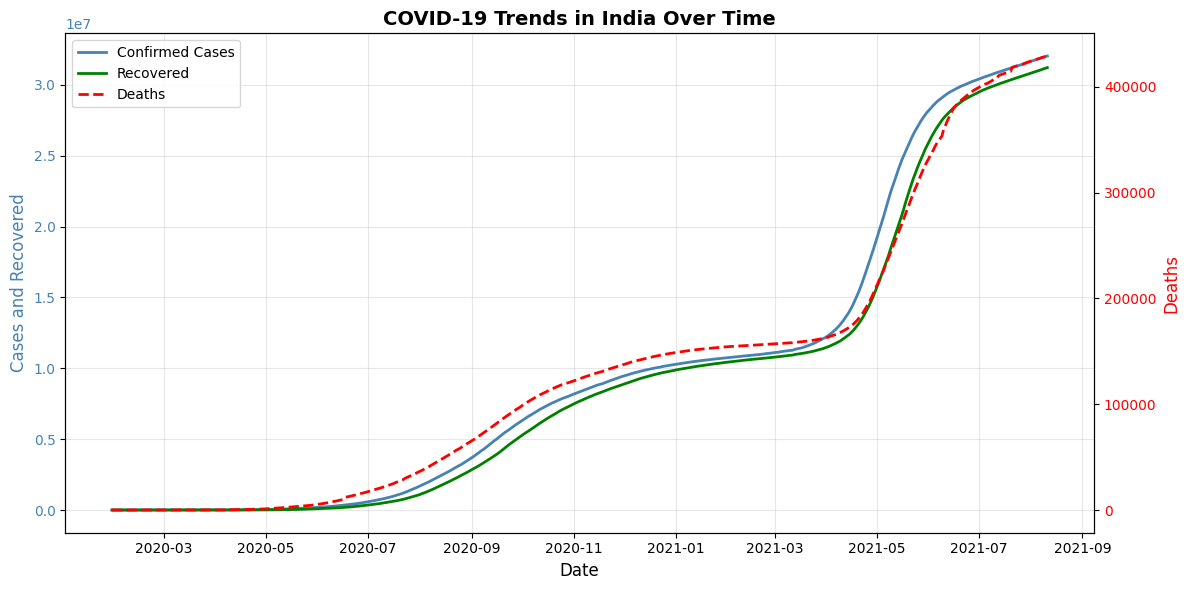

✅ Graph with two y-axes saved!


In [33]:
# National trend over time with TWO y-axes
daily_national = df.groupby('Date')[['Confirmed', 'Deaths', 'Cured']].sum()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Left y-axis for Cases and Recovered
ax1.plot(daily_national.index, daily_national['Confirmed'], 
         label='Confirmed Cases', color='steelblue', linewidth=2)
ax1.plot(daily_national.index, daily_national['Cured'], 
         label='Recovered', color='green', linewidth=2)
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Cases and Recovered', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(True, alpha=0.3)

# Right y-axis for Deaths
ax2 = ax1.twinx()
ax2.plot(daily_national.index, daily_national['Deaths'], 
         label='Deaths', color='red', linewidth=2, linestyle='--')
ax2.set_ylabel('Deaths', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legend
plt.title('COVID-19 Trends in India Over Time', fontsize=14, fontweight='bold')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('national_trends_dual_axis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Graph with two y-axes saved!")

=== RECOVERY ANALYSIS ===
National Recovery Rate: 97.45%

Top 10 states by recovery rate:
                                          Confirmed    Cured  Recovery_Rate
State/UnionTerritory                                                       
Dadra and Nagar Haveli and Daman and Diu      10654    10646      99.924911
Lakshadweep                                   10263    10165      99.045114
Rajasthan                                    953851   944700      99.040626
Gujarat                                      825085   814802      98.753704
Haryana                                      770114   759790      98.659419
Madhya Pradesh                               791980   781330      98.655269
Chandigarh                                    61992    61150      98.641760
Uttar Pradesh                               1708812  1685492      98.635309
Bihar                                        725279   715352      98.631285
Ladakh                                        20411    20130      98.62329

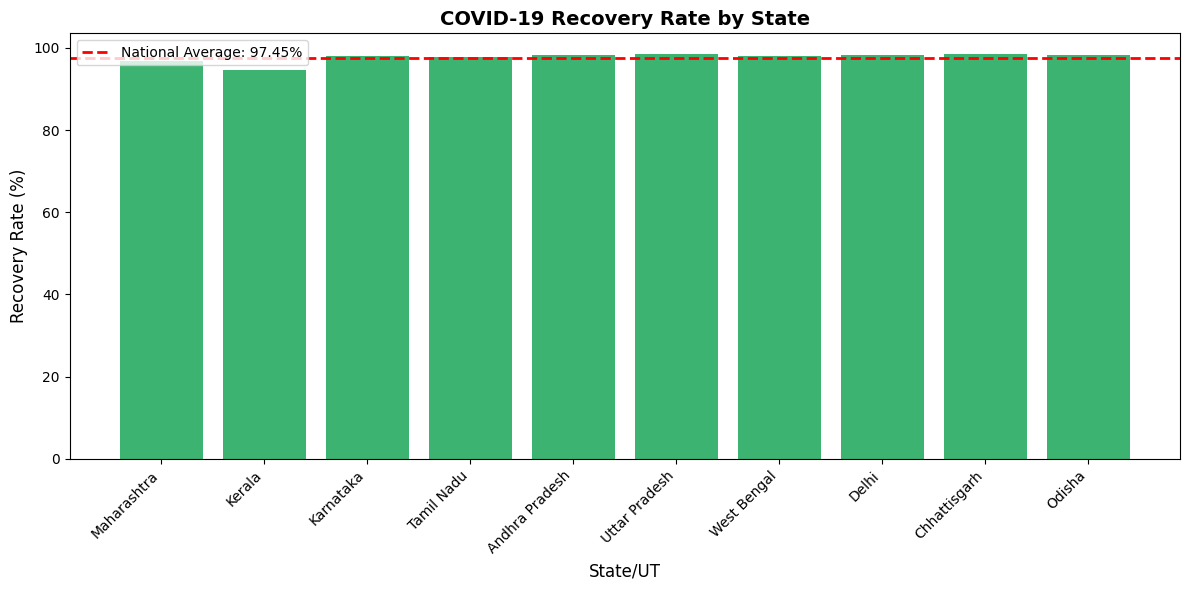

✅ Recovery rate analysis complete!


In [34]:
# Calculate Recovery Rate
latest_data['Recovery_Rate'] = (latest_data['Cured'] / latest_data['Confirmed']) * 100
national_recovery = (national_cured / national_confirmed) * 100

print("=== RECOVERY ANALYSIS ===")
print(f"National Recovery Rate: {national_recovery:.2f}%")
print("\nTop 10 states by recovery rate:")
print(latest_data.nlargest(10, 'Recovery_Rate')[['Confirmed', 'Cured', 'Recovery_Rate']])

# Quick visualization
top_recovery = latest_data.nlargest(10, 'Confirmed')
plt.figure(figsize=(12, 6))
plt.bar(range(len(top_recovery)), top_recovery['Recovery_Rate'], color='mediumseagreen')
plt.xticks(range(len(top_recovery)), top_recovery.index, rotation=45, ha='right')
plt.xlabel('State/UT', fontsize=12)
plt.ylabel('Recovery Rate (%)', fontsize=12)
plt.title('COVID-19 Recovery Rate by State', fontsize=14, fontweight='bold')
plt.axhline(y=national_recovery, color='red', linestyle='--', linewidth=2, 
            label=f'National Average: {national_recovery:.2f}%')
plt.legend()
plt.tight_layout()
plt.savefig('recovery_rate_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Recovery rate analysis complete!")

In [36]:
# Calculate Active Cases
latest_data['Active'] = latest_data['Confirmed'] - latest_data['Deaths'] - latest_data['Cured']
latest_data['Active_Rate'] = (latest_data['Active'] / latest_data['Confirmed']) * 100

print("=== ACTIVE CASES ANALYSIS ===")
national_active = national_confirmed - national_deaths - national_cured
national_active_rate = (national_active / national_confirmed) * 100

print(f"National Active Cases: {national_active:,}")
print(f"National Active Case Rate: {national_active_rate:.2f}%")
print("\nTop 10 states by active case rate:")
print(latest_data.nlargest(10, 'Active_Rate')[['Confirmed', 'Active', 'Active_Rate']])

=== ACTIVE CASES ANALYSIS ===
National Active Cases: 386,351
National Active Case Rate: 1.21%

Top 10 states by active case rate:
                      Confirmed  Active  Active_Rate
State/UnionTerritory                                
Mizoram                   46320   12427    26.828584
Sikkim                    28018    2567     9.161967
Manipur                  105424    6984     6.624677
Meghalaya                 69769    4427     6.345225
Arunachal Pradesh         50605    2536     5.011363
Kerala                  3586693  172505     4.809584
Nagaland                  28811    1374     4.769012
Tripura                   80660    2076     2.573766
Assam                    576149   11045     1.917039
Telangana                650353    8112     1.247323


In [37]:
# Create comprehensive summary table for top 10 states
top_10_summary = latest_data.nlargest(10, 'Confirmed')[['Confirmed', 'Deaths', 'Cured', 'Active', 'CFR', 'Recovery_Rate', 'Active_Rate']]

print("=== COMPREHENSIVE STATE SUMMARY ===")
print(top_10_summary.round(2))

# Save to CSV for reference
top_10_summary.to_csv('state_summary_statistics.csv')
print("\n✅ Summary table saved to CSV!")

=== COMPREHENSIVE STATE SUMMARY ===
                      Confirmed  Deaths    Cured  Active   CFR  Recovery_Rate  \
State/UnionTerritory                                                            
Maharashtra             6363442  134201  6159676   69565  2.11          96.80   
Kerala                  3586693   18004  3396184  172505  0.50          94.69   
Karnataka               2921049   36848  2861499   22702  1.26          97.96   
Tamil Nadu              2579130   34367  2524400   20363  1.33          97.88   
Andhra Pradesh          1985182   13564  1952736   18882  0.68          98.37   
Uttar Pradesh           1708812   22775  1685492     545  1.33          98.64   
West Bengal             1534999   18252  1506532   10215  1.19          98.15   
Delhi                   1436852   25068  1411280     504  1.74          98.22   
Chhattisgarh            1003356   13544   988189    1623  1.35          98.49   
Odisha                   988997    6565   972710    9722  0.66          9

In [47]:
# Print comma-separated list
top_10_states_list = latest_data.nlargest(10, 'Confirmed').index.tolist()
print(", ".join(top_10_states_list))

Maharashtra, Kerala, Karnataka, Tamil Nadu, Andhra Pradesh, Uttar Pradesh, West Bengal, Delhi, Chhattisgarh, Odisha


In [51]:
print(latest_data.nlargest(3,'Confirmed')['Confirmed'].sum()/latest_data['Confirmed'].sum()*100)

40.17660974380138


In [52]:
top_10_for_cfr['CFR']

State/UnionTerritory
Maharashtra       2.108937
Kerala            0.501967
Karnataka         1.261465
Tamil Nadu        1.332504
Andhra Pradesh    0.683262
Uttar Pradesh     1.332797
West Bengal       1.189056
Delhi             1.744647
Chhattisgarh      1.349870
Odisha            0.663804
Name: CFR, dtype: float64

In [53]:
# Get recovery rate range
lowest_recovery = latest_data['Recovery_Rate'].min()
highest_recovery = latest_data['Recovery_Rate'].max()

print(f"Recovery Rate Range: {lowest_recovery:.2f}% to {highest_recovery:.2f}%")

# Also get which states
lowest_state = latest_data['Recovery_Rate'].idxmin()
highest_state = latest_data['Recovery_Rate'].idxmax()

print(f"Lowest: {lowest_recovery:.2f}% ({lowest_state})")
print(f"Highest: {highest_recovery:.2f}% ({highest_state})")

Recovery Rate Range: 72.80% to 99.92%
Lowest: 72.80% (Mizoram)
Highest: 99.92% (Dadra and Nagar Haveli and Daman and Diu)
